In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from aquarel import load_theme

MASTER_DF_FE_PATH = Path("../data/processed/master_df_feature_engineered.parquet")
AVG_BASKET_SIZES_PATH = Path("../data/processed/avg_basket_sizes_df.parquet")
PRODUCTS_DF_PATH = Path("../data/processed/products_df.parquet")
USERS_DF_PATH = Path("../data/processed/users_df.parquet")

master_df_fe = pd.read_parquet(MASTER_DF_FE_PATH)
avg_basket_sizes_df = pd.read_parquet(AVG_BASKET_SIZES_PATH)
products_df = pd.read_parquet(PRODUCTS_DF_PATH)
users_df = pd.read_parquet(USERS_DF_PATH)

# Exploratory Data Analysis (EDA)

## Average Basket Sizes Dataframe Analysis

In [2]:
# look at the dataset
avg_basket_sizes_df.head()

,basket_size
0,5.900000
1,13.928571
2,7.333333
3,3.600000
4,9.250000


Are average basket sizes normally distributed?

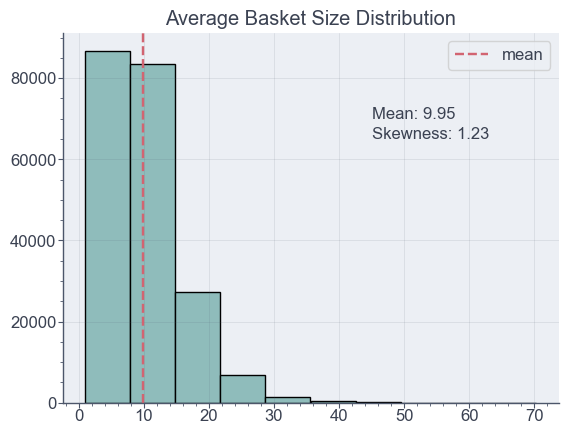

In [3]:
# setting theme and matplotlib params
plt.rcParams["font.family"] = "fantasy"
plt.rcParams["figure.titlesize"] = 18
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 10

theme = load_theme("arctic_light")
theme.apply()

# statistics
avg_basket_sizes_stats = avg_basket_sizes_df.agg(["mean", "skew", np.std]).round(2)

# plot
plt.hist(avg_basket_sizes_df.values, edgecolor="black")
plt.axvline(avg_basket_sizes_stats.iloc[0, 0], linestyle="--", color="#d26471", label="mean")
plt.text(45, 70000, s=f"Mean: {avg_basket_sizes_stats.iloc[0, 0]}")
plt.text(45, 65000, s=f"Skewness: {avg_basket_sizes_stats.iloc[1, 0]}")
plt.title("Average Basket Size Distribution")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## Products Dataframe Analysis

In [4]:
# look at dataframe
products_df.head()

,product_id,unique_order_ids,unique_user_ids,reordered_average
0,1,1852,716,0.613391
1,2,90,78,0.133333
2,3,277,74,0.732852
3,4,329,182,0.446809
4,5,15,6,0.600000


In [5]:
# shape
products_df.shape

(49677, 4)

In [6]:
# basic stats
products_df.describe(include=["int64", "float64"])

,unique_order_ids,unique_user_ids,reordered_average
count,49677.000000,49677.000000,49677.000000
mean,652.907563,267.889627,0.366461
std,4792.114416,1308.788623,0.208103
min,1.000000,1.000000,0.000000
25%,17.000000,11.000000,0.208075
50%,60.000000,35.000000,0.376623
75%,260.000000,137.000000,0.529307
max,472565.000000,73956.000000,0.941176


Do some products appear more often than others in orders?

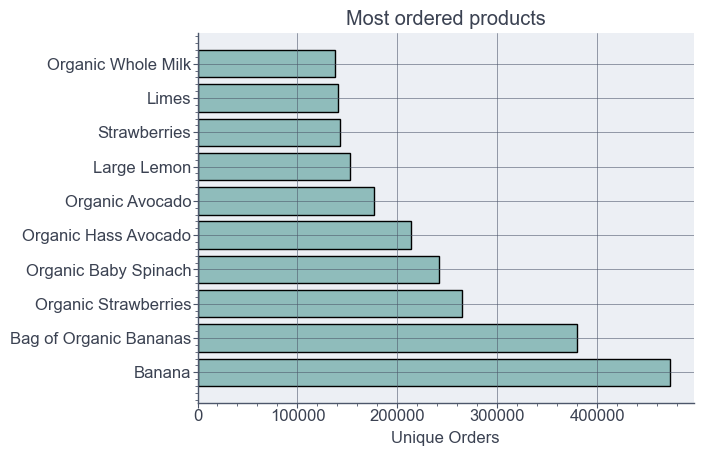

In [7]:
products_df = products_df.merge(master_df_fe[["product_id", "product_name"]].drop_duplicates(), on="product_id", how="left")
top_products = (products_df[["product_name", "unique_order_ids"]].sort_values(by="unique_order_ids", ascending=False).head(10))

plt.barh(top_products.product_name, top_products.unique_order_ids, edgecolor="black")
plt.title("Most ordered products")
plt.xlabel("Unique Orders")
plt.show()

## Users Dataframe Analysis

In [8]:
# look at the df
users_df.head()

,user_id,unique_orders,total_products_purchased,reordered_average
0,1,10,59,0.694915
1,2,14,195,0.476923
2,3,12,88,0.625000
3,4,5,18,0.055556
4,5,4,37,0.378378


Do some people order more than others? What is the distribution? Is it right-skewed?

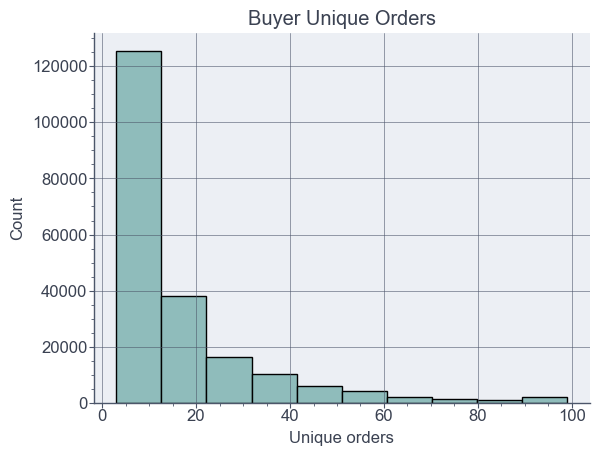

In [9]:
plt.hist(users_df.unique_orders.values, edgecolor="black", bins=10)
plt.xlabel("Unique orders")
plt.ylabel("Count")
plt.title("Buyer Unique Orders")
plt.show()

How many people reorder more than others?

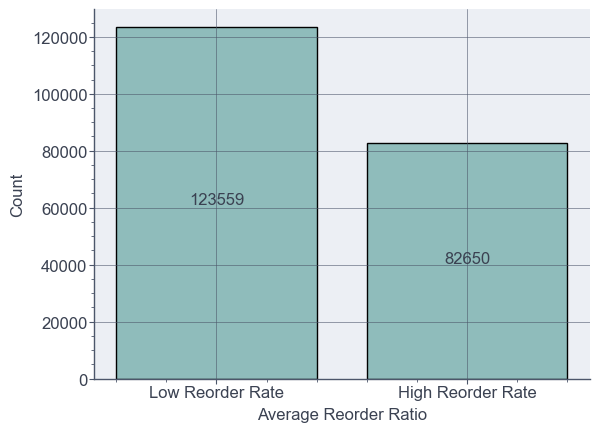

In [10]:
reorder_counts = users_df.reordered_average.value_counts(bins=2)
reorder_x = [1, 2]

reorder_bar = plt.bar(reorder_x, reorder_counts.values, edgecolor="black")
plt.xticks(reorder_x, labels=["Low Reorder Rate", "High Reorder Rate"])
plt.bar_label(reorder_bar, label_type="center", padding=2)
plt.xlabel("Average Reorder Ratio")
plt.ylabel("Count")
plt.show()

## Master Dataframe Analysis

In [11]:
# look at the dataframe
master_df_fe.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,part_of_day_purchase,product_name_length,days_since_prior_order_missing
0,2539329,1,prior,1,2,8,NaN,196,1,0,Soda,77,7,soft drinks,beverages,morning,4,1
1,2539329,1,prior,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs,morning,39,1
2,2539329,1,prior,1,2,8,NaN,12427,3,0,Original Beef Jerky,23,19,popcorn jerky,snacks,morning,19,1
3,2539329,1,prior,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks,morning,26,1
4,2539329,1,prior,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household,morning,32,1


In [12]:
# shape
master_df_fe.shape

(32434489, 18)

In [13]:
# info
master_df_fe.info(memory_usage="deep", show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 18 columns):
 #   Column                          Non-Null Count     Dtype   
---  ------                          --------------     -----   
 0   order_id                        32434489 non-null  int32   
 1   user_id                         32434489 non-null  int32   
 2   eval_set                        32434489 non-null  category
 3   order_number                    32434489 non-null  int16   
 4   order_dow                       32434489 non-null  int8    
 5   order_hour_of_day               32434489 non-null  int8    
 6   days_since_prior_order          30356421 non-null  float64 
 7   product_id                      32434489 non-null  int32   
 8   add_to_cart_order               32434489 non-null  int16   
 9   reordered                       32434489 non-null  int8    
 10  product_name                    32434489 non-null  str     
 11  aisle_id                        32434489 non-n

In [14]:
# basic stats
master_df_fe.describe(include=["int64", "int32", "int16", "int8", "float64"]).round(2)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle_id,department_id,product_name_length,days_since_prior_order_missing
count,32434489.00,32434489.00,32434489.00,32434489.00,32434489.00,30356421.00,32434489.00,32434489.00,32434489.00,32434489.00,32434489.00,32434489.00,32434489.00
mean,1710748.52,102937.24,17.14,2.74,13.42,11.10,25576.34,8.35,0.59,71.21,9.92,25.04,0.06
std,987300.70,59466.48,17.54,2.09,4.25,8.78,14096.69,7.13,0.49,38.20,6.28,11.82,0.24
min,2.00,1.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,3.00,0.00
25%,855943.00,51421.00,5.00,1.00,10.00,5.00,13530.00,3.00,0.00,31.00,4.00,17.00,0.00
50%,1711048.00,102611.00,11.00,3.00,13.00,8.00,25256.00,6.00,1.00,83.00,9.00,22.00,0.00
75%,2565514.00,154391.00,24.00,5.00,16.00,15.00,37935.00,11.00,1.00,107.00,16.00,31.00,0.00
max,3421083.00,206209.00,99.00,6.00,23.00,30.00,49688.00,145.00,1.00,134.00,21.00,159.00,1.00


### Missing Values Analysis

In [15]:
# NaN values check
master_df_fe.isna().sum()

order_id                                0
user_id                                 0
eval_set                                0
order_number                            0
order_dow                               0
order_hour_of_day                       0
days_since_prior_order            2078068
product_id                              0
add_to_cart_order                       0
reordered                               0
product_name                            0
aisle_id                                0
department_id                           0
aisle                                   0
department                              0
part_of_day_purchase                    0
product_name_length                     0
days_since_prior_order_missing          0
dtype: int64

How many missing values does "days_since_prior_order" have? % of total

In [16]:
rows, cols = master_df_fe.shape
(master_df_fe.days_since_prior_order.isna().sum() / rows) * 100

np.float64(6.406970062022559)

### Target Variable Analysis

How many reordered the same product?

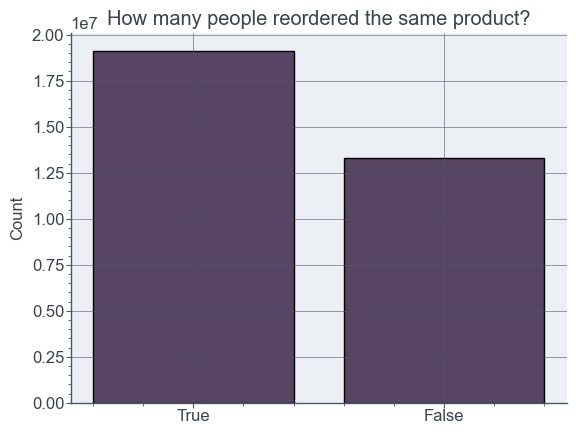

In [17]:
reorder_counts = master_df_fe.reordered.value_counts()
reorder_counts_x = [0, 1]

plt.bar(reorder_counts_x, reorder_counts.values, edgecolor="black", color="#584563")
plt.xticks(reorder_counts_x, labels=["True", "False"])
plt.title("How many people reordered the same product?")
plt.ylabel("Count")
plt.show()

What is the total %?

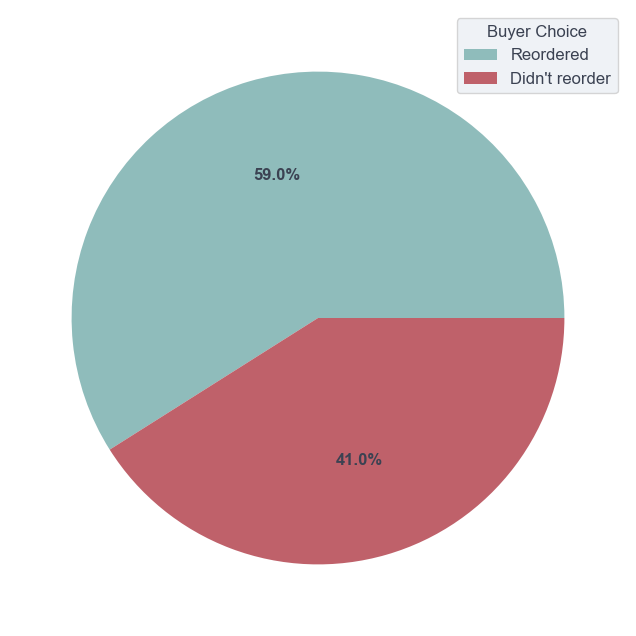

In [18]:
reorder_count_perc = master_df_fe.reordered.value_counts(normalize=True)

plt.figure(figsize=(11, 8))
wedges, texts, autotexts = plt.pie(reorder_count_perc.values, autopct="%1.1f%%")
plt.legend(wedges, ["Reordered", "Didn't reorder"], title="Buyer Choice", loc="best")
plt.setp(autotexts, size=12, weight="bold")
plt.show()

### Numerical Features Analysis

In [19]:
# look at numerical features
master_df_fe.select_dtypes(include="number")

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle_id,department_id,product_name_length,days_since_prior_order_missing
0,2539329,1,1,2,8,NaN,196,1,0,77,7,4,1
1,2539329,1,1,2,8,NaN,14084,2,0,91,16,39,1
2,2539329,1,1,2,8,NaN,12427,3,0,23,19,19,1
3,2539329,1,1,2,8,NaN,26088,4,0,23,19,26,1
4,2539329,1,1,2,8,NaN,26405,5,0,54,17,32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32434484,2977660,206209,13,1,12,7.0,14197,5,1,9,9,12,0
32434485,2977660,206209,13,1,12,7.0,38730,6,0,3,19,31,0
32434486,2977660,206209,13,1,12,7.0,31477,7,0,3,19,37,0
32434487,2977660,206209,13,1,12,7.0,6567,8,0,3,19,35,0


Do people order more in certain days of the week?

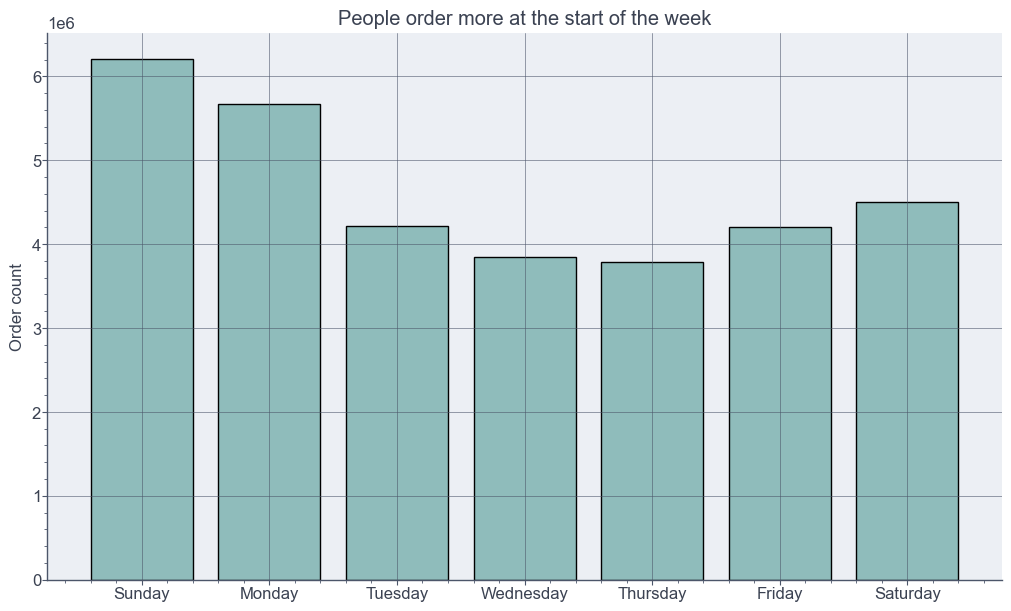

In [20]:
day_orders = master_df_fe.groupby("order_dow").size()
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

plt.figure(figsize=(10, 6), layout="constrained")
plt.bar(days, day_orders.values, edgecolor="black")
plt.title("People order more at the start of the week")
plt.ylabel("Order count")
plt.show()

Do buyers order more in certain hours of the day? 

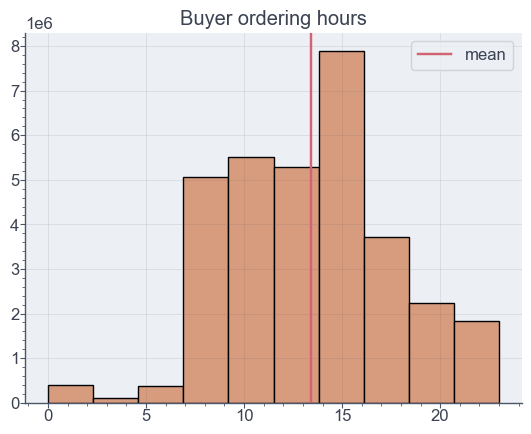

In [21]:
plt.hist(master_df_fe.order_hour_of_day.values, edgecolor="black", color="#d79b7d")
plt.title("Buyer ordering hours")
plt.axvline(master_df_fe.order_hour_of_day.mean(), color="#d26471", label="mean")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

How is product_name_length distributed? Do people order more "lengthy" products? Are there outliers?

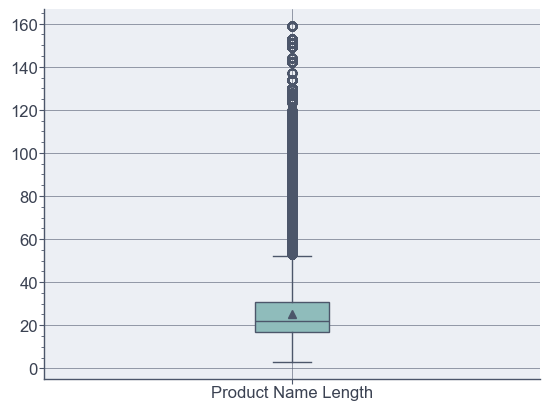

In [22]:
plt.boxplot([master_df_fe.product_name_length.values], patch_artist=True, showmeans=True, showcaps=True, tick_labels=["Product Name Length"])
plt.show()

### Categorical Features Analysis

In [23]:
# look at the categories
master_df_fe.select_dtypes(include=["str", "category"])

,eval_set,product_name,aisle,department,part_of_day_purchase
0,prior,Soda,soft drinks,beverages,morning
1,prior,Organic Unsweetened Vanilla Almond Milk,soy lactosefree,dairy eggs,morning
2,prior,Original Beef Jerky,popcorn jerky,snacks,morning
3,prior,Aged White Cheddar Popcorn,popcorn jerky,snacks,morning
4,prior,XL Pick-A-Size Paper Towel Rolls,paper goods,household,morning
...,...,...,...,...,...
32434484,prior,Tomato Paste,pasta sauce,dry goods pasta,afternoon
32434485,prior,Brownie Crunch High Protein Bar,energy granola bars,snacks,afternoon
32434486,prior,High Protein Bar Chunky Peanut Butter,energy granola bars,snacks,afternoon
32434487,prior,Chocolate Peanut Butter Protein Bar,energy granola bars,snacks,afternoon


Are some aisles preferred than others? Also, what about deparments?

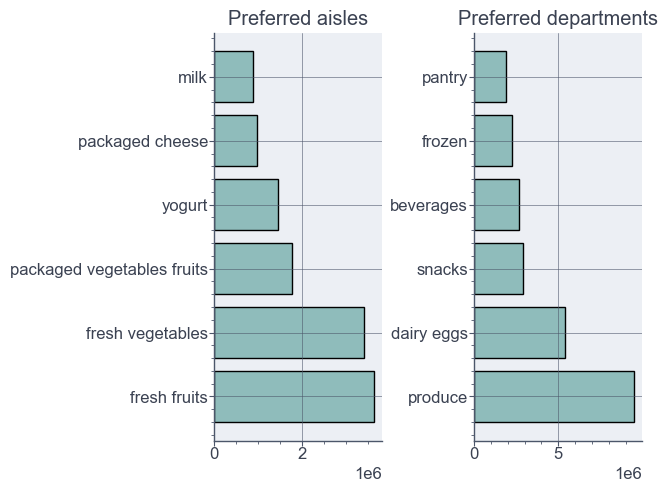

In [24]:
most_preferred_aisles = master_df_fe.aisle.value_counts(ascending=False).nlargest(6)
most_preferred_departments = master_df_fe.department.value_counts(ascending=False).nlargest(6)

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True)
axes[0].barh(most_preferred_aisles.index, most_preferred_aisles.values, edgecolor="black")
axes[0].set_title("Preferred aisles")
axes[1].barh(most_preferred_departments.index, most_preferred_departments.values, edgecolor="black")
axes[1].set_title("Preferred departments")
plt.show()

How many people prefer the morning compared to other parts of the day?

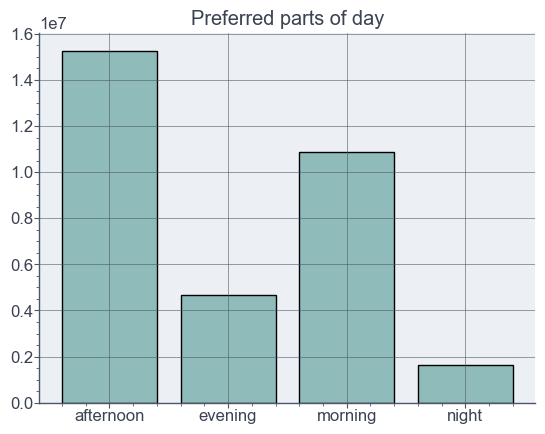

In [25]:
part_of_day_counts = master_df_fe.groupby("part_of_day_purchase").size()

plt.bar(part_of_day_counts.index, part_of_day_counts.values, edgecolor="black")
plt.title("Preferred parts of day")
plt.show()

### Target Relationships

Are afternoon people more likely to reorder?

In [26]:
pd.crosstab(master_df_fe.part_of_day_purchase, master_df_fe.reordered, normalize="index")

reordered,0,1
part_of_day_purchase,,
afternoon,0.420720,0.579280
evening,0.421563,0.578437
morning,0.389042,0.610958
night,0.422117,0.577883


Does day of week have any influence on reordering?

In [27]:
# remember: 0 is sunday, 1 monday and so on...
pd.crosstab(master_df_fe.order_dow, master_df_fe.reordered, normalize="index")

reordered,0,1
order_dow,,
0,0.414724,0.585276
1,0.396157,0.603843
2,0.410229,0.589771
3,0.413728,0.586272
4,0.409021,0.590979
5,0.404530,0.595470
6,0.425631,0.574369


### Correlation Analysis

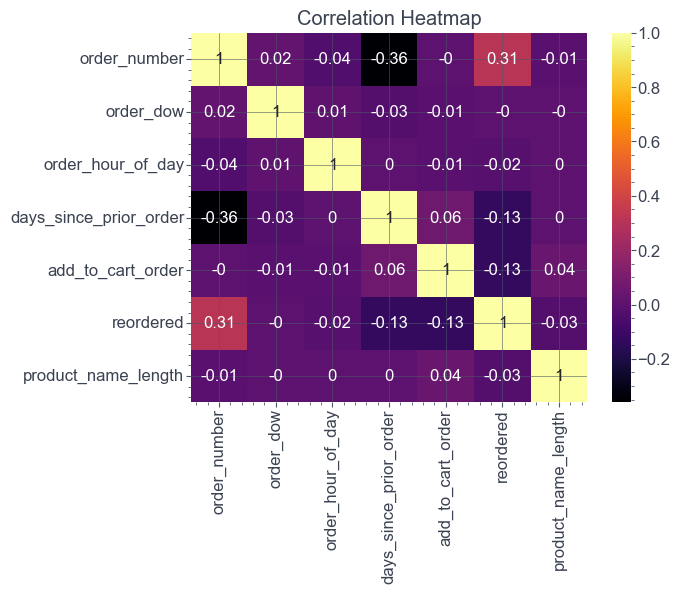

In [28]:
corr_columns = ["order_number", "order_dow", "order_hour_of_day", "days_since_prior_order", "add_to_cart_order", "reordered", "product_name_length"]
corr = master_df_fe[corr_columns].sample(n=500_000, random_state=42).corr().round(2)

# visualize it
sns.heatmap(data=corr, annot=True, cmap="inferno")
plt.title("Correlation Heatmap")
plt.show()

### Group Analysis

Do people who order in the morning prefer certain hours? Also what about the other parts of the day?

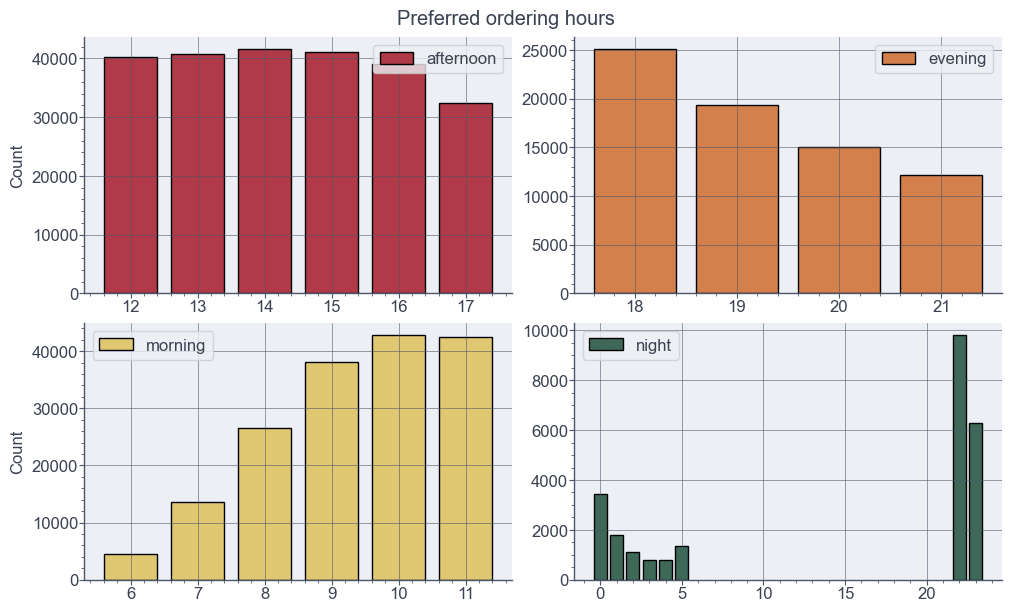

In [29]:
preferred_hours = master_df_fe.sample(n=500_000, random_state=42).groupby(["part_of_day_purchase", "order_hour_of_day"]).size()


fig, axes = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(10, 6))

axes[0, 0].bar(preferred_hours.afternoon.index, preferred_hours.afternoon.values, edgecolor="black", color="#b03a48", label="afternoon")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()
axes[0, 1].bar(preferred_hours.evening.index, preferred_hours.evening.values, edgecolor="black", color="#d4804d", label="evening")
axes[0, 1].legend()
axes[1, 0].bar(preferred_hours.morning.index, preferred_hours.morning.values, edgecolor="black", color="#e0c872", label="morning")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()
axes[1, 1].bar(preferred_hours.night.index, preferred_hours.night.values, edgecolor="black", color="#3e6958", label="night")
axes[1, 1].legend()
plt.suptitle("Preferred ordering hours")
plt.show()

# Exploratory Data Analysis Conclusions

## Average Basket Sizes Analysis

1.	Average basket sizes aren’t normally distributed, as confirmed by the positive skewness of 1.23. The distribution is right-skewed, meaning most orders contain a moderate number of products, while a smaller subset of orders contain unusually large baskets.

## Products Dataframe Analysis

1. The most ordered products are bananas, organic strawberries and organic baby spinach. This confirms the categorical finding about the most popular aisle (fresh fruits) and department (produce).

## Users Dataframe Analysis

1.	Unique buyer orders aren’t normally distributed as shown by the right-skewed distribution. 
2.	123.6k users reorder products less than half the time, while 82.7k users reorder products more consistently.

## Master Dataframe Analysis

1.	The column with the most missing values is “days_since_prior_order”, with NaN values representing 6.4% of the data. The number isn’t small but has to be taken into account when choosing an imputer for training machine learning models.
2.	Target Variable Analysis: Approximately 59% of purchase events correspond to reordered products, suggesting that repeat purchasing behavior is common.
3.	Numerical Features Analysis: 
-	People order more on Sunday and Monday. The trend decreases during the week until Thursday, when reorders pick up back again. 
-	In terms of ordering hours, people generally prefer to order during late morning and the first part of the afternoon. As the day ends, people order less.
-	Most product names are relatively short, although some extreme outliers exist. 
4.	Categorical Features Analysis:
-	According to the dataset, the preferred aisles are fresh fruits, fresh vegetables and packaged vegetables fruits. In terms of departments, produce remains at the top, followed by dairy eggs.
-	As I wrote in the numerical features analysis, people order more during late morning/early afternoon. This is confirmed by the categorical analysis of the preferred parts of the day, which are afternoon and morning.
5.	Target Relationships: 
-	Part of the day purchase doesn’t indicate, according to the data, a significantly higher reordering probability. Afternoon, evening and night stay at roughly 58%, with morning only at 61%.
-	The same thing can be said about days of the week: reordering probability range from 57% to 60%.
6.	Correlation Analysis:
-	Among numerical features, “order_number” reaches a higher correlation compared to the other ones, namely, 0.31. Most of the features are negatively correlated actually. For some (for ex. days since prior order) it makes sense since, as the fewer days from another order, the more likely the person will reorder.
7.	Group Analysis:
-	To note, according to the data, people prefer ordering during the late hours of the morning, particularly 10 and 11 am. Afternoon purchases appear more evenly distributed across hours while in the evening people tend to prefer 18 am, with the trend declining until 21 am.